# Xac dinh co phai nen Doji hay khong
- Nen Doji khi than nen < 0.1% cua O hoac C

# Load data len

### Viet ham

In [27]:
def loadDataSSI(symbol, from_date, to_date):
    # Import necessary modules
    from ssi_fc_data import fc_md_client, model
    import pandas as pd  # Import Pandas for DataFrame handling
    import json
    import configDataSSI

    # Create a Market Data Client
    # from_date = "08/08/2024"
    # to_date = "15/11/2024"
    client = fc_md_client.MarketDataClient(configDataSSI)

    req = model.daily_ohlc(symbol, from_date, to_date)

    data_dict = client.daily_ohlc(configDataSSI, req)

    # Access the list of dictionaries in the "data" field
    data_list = data_dict['data']

    # Convert the list of dictionaries into a DataFrame
    data = pd.DataFrame(data_list, columns=['TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume'])
    data = data.rename(columns={'TradingDate': 'Datetime'})

    # Print or work with the DataFrame
    return data

In [28]:
symbol = 'VCB'
from_date = '01/05/2025'
to_date = '05/08/2025'
data = loadDataSSI('VCB', from_date=from_date, to_date=to_date)
data

,Datetime,Open,High,Low,Close,Volume
0,05/05/2025,57500,58000,57000,57100,2101500
1,06/05/2025,57300,58000,57000,57000,2992900
2,07/05/2025,57100,57500,57000,57000,2415400
3,08/05/2025,57400,57700,56900,57100,3022300
4,09/05/2025,57300,57600,56600,56600,5827400
...,...,...,...,...,...,...
62,30/07/2025,61000,61900,60400,60900,7271000
63,31/07/2025,61500,61700,60100,60200,6066900
64,01/08/2025,60300,60600,59700,60200,4751600
65,04/08/2025,60100,61400,60000,61100,4462400


# Xac dinh nen Doji

In [29]:
import pandas as pd

data['Open'] = pd.to_numeric(data['Open'])
data['Close'] = pd.to_numeric(data['Close'])

data['IsDoji'] = abs(data['Open'] - data['Close']) < 0.1/100 * data['Close']

data

,Datetime,Open,High,Low,Close,Volume,IsDoji
0,05/05/2025,57500,58000,57000,57100,2101500,False
1,06/05/2025,57300,58000,57000,57000,2992900,False
2,07/05/2025,57100,57500,57000,57000,2415400,False
3,08/05/2025,57400,57700,56900,57100,3022300,False
4,09/05/2025,57300,57600,56600,56600,5827400,False
...,...,...,...,...,...,...,...
62,30/07/2025,61000,61900,60400,60900,7271000,False
63,31/07/2025,61500,61700,60100,60200,6066900,False
64,01/08/2025,60300,60600,59700,60200,4751600,False
65,04/08/2025,60100,61400,60000,61100,4462400,False


# Backtest: Thi chac chan phai co chien luoc

In [30]:
# Tín hiệu mua khi Open >= Close và là nến Doji
data['Buy_Signal'] = (data["Open"] >= data["Close"]) & data["IsDoji"]
# Tín hiệu bán khi Open <= Close và là nến Doji  
data['Sell_Signal'] = (data["Open"] < data["Close"]) & data["IsDoji"]

In [31]:
data

,Datetime,Open,High,Low,Close,Volume,IsDoji,Buy_Signal,Sell_Signal
0,05/05/2025,57500,58000,57000,57100,2101500,False,False,False
1,06/05/2025,57300,58000,57000,57000,2992900,False,False,False
2,07/05/2025,57100,57500,57000,57000,2415400,False,False,False
3,08/05/2025,57400,57700,56900,57100,3022300,False,False,False
4,09/05/2025,57300,57600,56600,56600,5827400,False,False,False
...,...,...,...,...,...,...,...,...,...
62,30/07/2025,61000,61900,60400,60900,7271000,False,False,False
63,31/07/2025,61500,61700,60100,60200,6066900,False,False,False
64,01/08/2025,60300,60600,59700,60200,4751600,False,False,False
65,04/08/2025,60100,61400,60000,61100,4462400,False,False,False


In [19]:
data.to_csv('Buoi 8.Bai tap tai lop 2.csv', index=False)

# Set index la Datetime

In [32]:
# Set index la Datettime
data = data.set_index('Datetime')

In [33]:
data

,Open,High,Low,Close,Volume,IsDoji,Buy_Signal,Sell_Signal
Datetime,,,,,,,,
05/05/2025,57500,58000,57000,57100,2101500,False,False,False
06/05/2025,57300,58000,57000,57000,2992900,False,False,False
07/05/2025,57100,57500,57000,57000,2415400,False,False,False
08/05/2025,57400,57700,56900,57100,3022300,False,False,False
09/05/2025,57300,57600,56600,56600,5827400,False,False,False
...,...,...,...,...,...,...,...,...
30/07/2025,61000,61900,60400,60900,7271000,False,False,False
31/07/2025,61500,61700,60100,60200,6066900,False,False,False
01/08/2025,60300,60600,59700,60200,4751600,False,False,False


# Su dung module Common.CommonBacktest

In [34]:
import sys
sys.path.append('../Common')

import CommonBacktest

# Backtest:
### Moi lan mua, la mua 100 CP, moi lan ban la ban All

### (Moi lan mua la ti le % tien, moi lan ban la ban All)

Ngày vào lệnh đầu tiên: 01/07/2025
Tổng lợi nhuận: 1430000
Tổng giá trị tài khoản: 101430000
Lợi nhuận thị trường: 7.705779334500876%
Lợi nhuận chiến lược: 1.43%


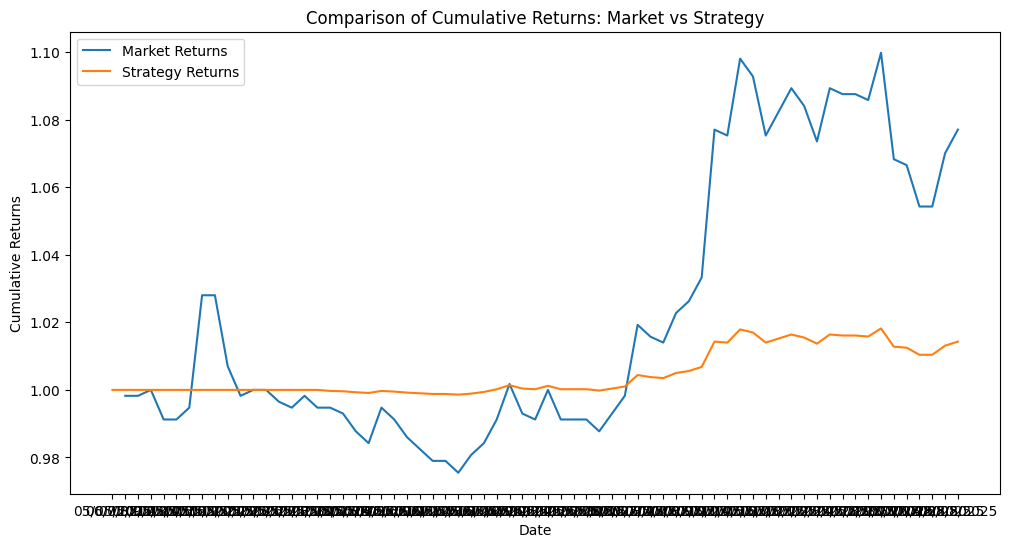

In [36]:
dataBacktest = CommonBacktest.CommonBacktest.backtest(data, initial_capital=100000000, shares_per_signal=100)

# Viet lai import Class

Ngày vào lệnh đầu tiên: 17
Tổng lợi nhuận: 1430000
Tổng giá trị tài khoản: 101430000
Lợi nhuận thị trường: 7.705779334500876%
Lợi nhuận chiến lược: 1.43%


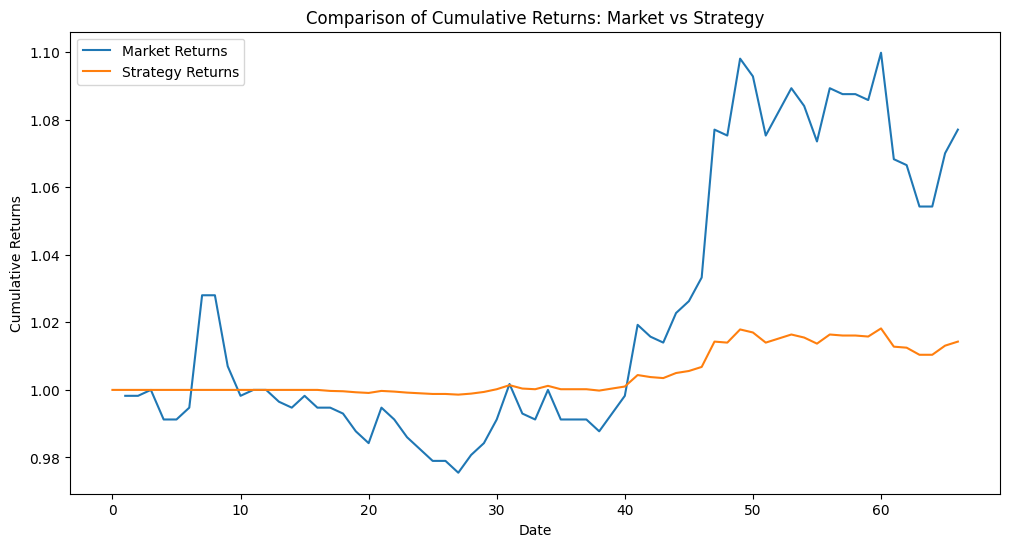

,Datetime,Open,High,Low,Close,Volume,IsDoji,Buy_Signal,Sell_Signal,Position_Buy,Position_Sell,Trade_Action,Capital,Shares_Held,Market_Return,Cumulative_Market_Returns,Strategy_Value,Cumulative_Strategy_Returns
0,05/05/2025,57500,58000,57000,57100,2101500,False,False,False,NaN,NaN,,100000000,0,NaN,NaN,100000000,1.0000
1,06/05/2025,57300,58000,57000,57000,2992900,False,False,False,False,False,,100000000,0,-0.001751,0.998249,100000000,1.0000
2,07/05/2025,57100,57500,57000,57000,2415400,False,False,False,False,False,,100000000,0,0.000000,0.998249,100000000,1.0000
3,08/05/2025,57400,57700,56900,57100,3022300,False,False,False,False,False,,100000000,0,0.001754,1.000000,100000000,1.0000
4,09/05/2025,57300,57600,56600,56600,5827400,False,False,False,False,False,,100000000,0,-0.008757,0.991243,100000000,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,30/07/2025,61000,61900,60400,60900,7271000,False,False,False,False,False,,82980000,300,-0.001639,1.066550,101250000,1.0125
63,31/07/2025,61500,61700,60100,60200,6066900,False,False,False,False,False,,82980000,300,-0.011494,1.054291,101040000,1.0104
64,01/08/2025,60300,60600,59700,60200,4751600,False,False,False,False,False,,82980000,300,0.000000,1.054291,101040000,1.0104
65,04/08/2025,60100,61400,60000,61100,4462400,False,False,False,False,False,,82980000,300,0.014950,1.070053,101310000,1.0131


In [20]:
import sys
sys.path.append('../Common')

from CommonBacktest import CommonBacktest # Nhin thay Class CommonBacktest

dataBacktestClass = CommonBacktest.backtest(data, initial_capital=100000000, shares_per_signal=100)

dataBacktestClass

In [21]:
dataBacktest

,Datetime,Open,High,Low,Close,Volume,IsDoji,Buy_Signal,Sell_Signal,Position_Buy,Position_Sell,Trade_Action,Capital,Shares_Held,Market_Return,Cumulative_Market_Returns,Strategy_Value,Cumulative_Strategy_Returns
0,05/05/2025,57500,58000,57000,57100,2101500,False,False,False,NaN,NaN,,100000000,0,NaN,NaN,100000000,1.0000
1,06/05/2025,57300,58000,57000,57000,2992900,False,False,False,False,False,,100000000,0,-0.001751,0.998249,100000000,1.0000
2,07/05/2025,57100,57500,57000,57000,2415400,False,False,False,False,False,,100000000,0,0.000000,0.998249,100000000,1.0000
3,08/05/2025,57400,57700,56900,57100,3022300,False,False,False,False,False,,100000000,0,0.001754,1.000000,100000000,1.0000
4,09/05/2025,57300,57600,56600,56600,5827400,False,False,False,False,False,,100000000,0,-0.008757,0.991243,100000000,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,30/07/2025,61000,61900,60400,60900,7271000,False,False,False,False,False,,82980000,300,-0.001639,1.066550,101250000,1.0125
63,31/07/2025,61500,61700,60100,60200,6066900,False,False,False,False,False,,82980000,300,-0.011494,1.054291,101040000,1.0104
64,01/08/2025,60300,60600,59700,60200,4751600,False,False,False,False,False,,82980000,300,0.000000,1.054291,101040000,1.0104
65,04/08/2025,60100,61400,60000,61100,4462400,False,False,False,False,False,,82980000,300,0.014950,1.070053,101310000,1.0131
